In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\afaqu\Downloads\global_startup_success_dataset.csv")

In [3]:
df.head()

,Startup Name,Founded Year,Country,Industry,Funding Stage,Total Funding ($M),Number of Employees,Annual Revenue ($M),Valuation ($B),Success Score,Acquired?,IPO?,Customer Base (Millions),Tech Stack,Social Media Followers
0,Startup_1,2009,Canada,Healthcare,Series A,269,3047,104,46.11,5,No,No,43,"Java, Spring",4158814
1,Startup_2,2004,UK,Healthcare,IPO,40,630,431,33.04,1,No,Yes,64,"Node.js, React",4063014
2,Startup_3,2018,USA,Healthcare,Seed,399,2475,375,15.79,8,No,No,74,"PHP, Laravel",3449855
3,Startup_4,2014,France,Tech,Seed,404,1011,907,17.12,7,Yes,Yes,26,"Python, AI",630421
4,Startup_5,2006,Japan,Energy,Series C,419,3917,280,4.39,6,Yes,Yes,30,"Node.js, React",365956


In [4]:
df.shape

(5000, 15)

In [5]:
df.isnull().sum()

Startup Name                0
Founded Year                0
Country                     0
Industry                    0
Funding Stage               0
Total Funding ($M)          0
Number of Employees         0
Annual Revenue ($M)         0
Valuation ($B)              0
Success Score               0
Acquired?                   0
IPO?                        0
Customer Base (Millions)    0
Tech Stack                  0
Social Media Followers      0
dtype: int64

In [6]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")
df.columns = df.columns.str.replace("$", "")

In [7]:
#converting yes/no to binary to build models
df['Acquired?'] = df['Acquired?'].map({'Yes':1, 'No':0})
df['IPO?'] = df['IPO?'].map({'Yes':1, 'No':0})

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.to_csv("startup_success_cleaned.csv", index=False)

In [10]:
#eda
import matplotlib.pyplot as plt
import seaborn as sns

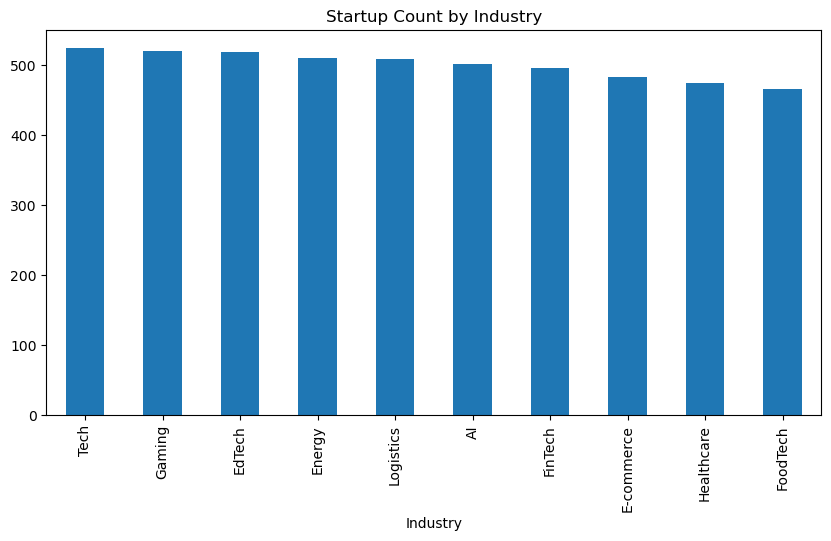

In [11]:
plt.figure(figsize=(10,5))
df['Industry'].value_counts().plot(kind='bar')
plt.title("Startup Count by Industry")
plt.show()

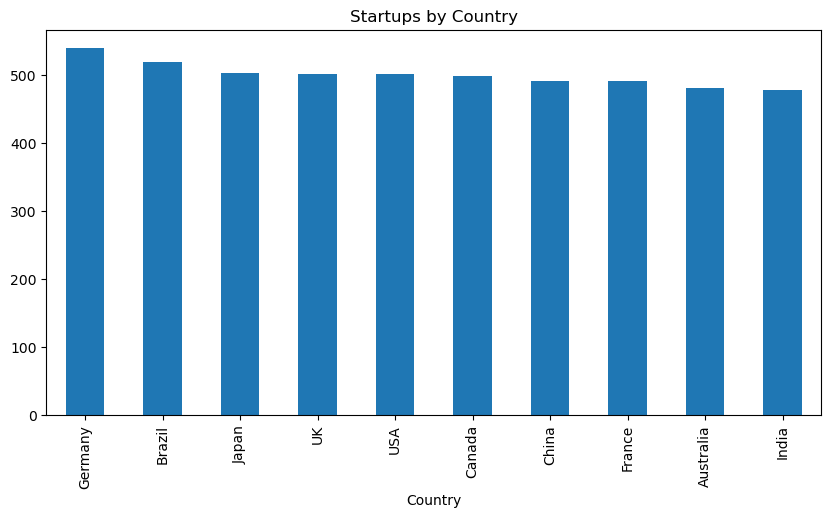

In [12]:
plt.figure(figsize=(10,5))
df['Country'].value_counts().plot(kind='bar')
plt.title("Startups by Country")
plt.show()

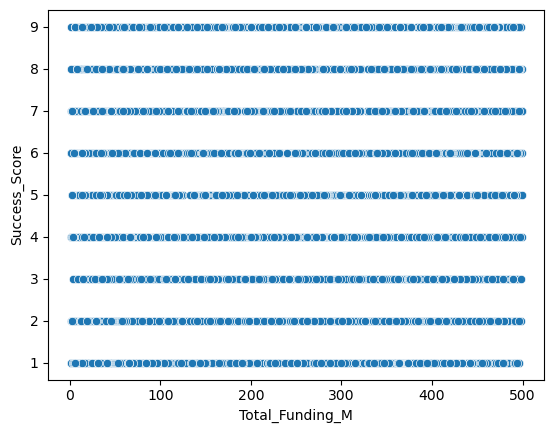

In [17]:
#funding vs success
sns.scatterplot(x='Total_Funding_M', y='Success_Score', data=df)
plt.show()

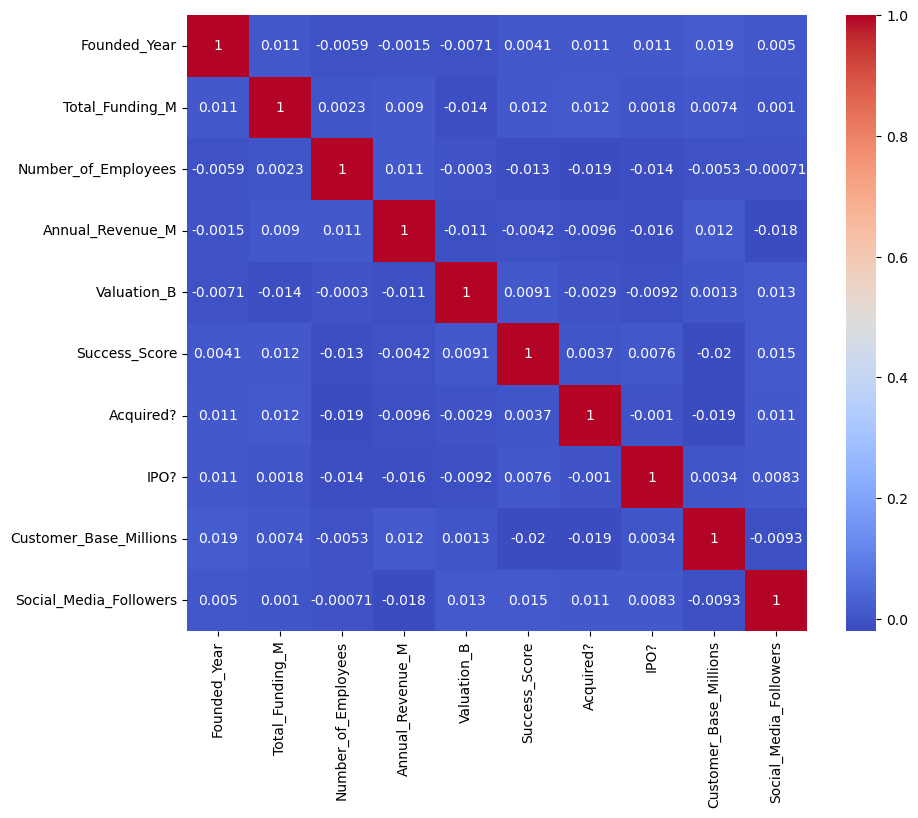

In [18]:
#corr matrix-which feature influences success score
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

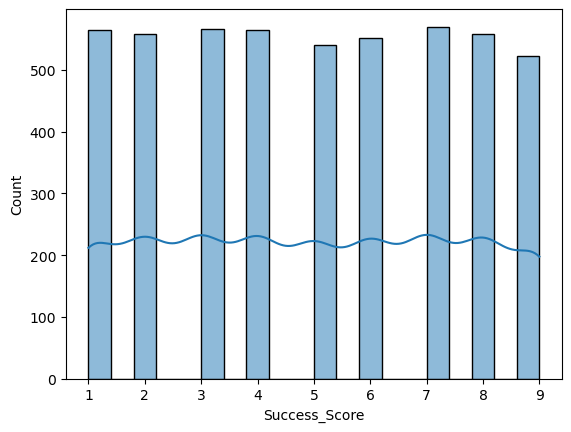

In [20]:
#success score distribution
sns.histplot(df['Success_Score'], bins=20, kde=True)
plt.show()

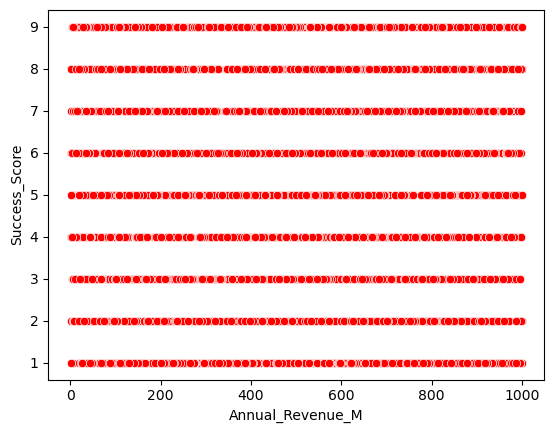

In [22]:
#revenue vs success
sns.scatterplot(x='Annual_Revenue_M', y='Success_Score', data=df,color='red')
plt.show()